# BMW Days-on-Lot Prediction — Duke Data Project

**Dataset:** `data-duke-project 20260311-V4_NO-VIN.xlsx` (11,008 vehicles, 5 dealers, March 2023–March 2026)

**Target:** `days_on_lot` capped at **90 days** — vehicles sitting longer than 90 days are treated as a separate operational problem (aged inventory), and including extreme outliers (up to 1,060 days) would distort the model.

### Priority Mapping (from Mike's table)
| Prod PTY | Distr PTY | Business Type | Order Type |
|---|---|---|---|
| 3 | 2 | Regular | Customer |
| 4 | 2 | Regular | Customer |
| 5 | 3 | Regular | Demonstrator / Preferred Stock / Unverified Customer |
| 6 | 3 | Regular | Preferred Stock |
| 8 | 3 | Regular | Non-preferred Stock |

### Three Models (Basic → Strong)
1. **Ridge Regression** — linear baseline, fully interpretable
2. **LightGBM** — gradient boosted trees, strong on tabular data
3. **Neural Network (MLP)** — 4-layer deep network with batch norm and dropout

### Explainability
- SHAP summary plots, bar plots, and waterfall/force plots for all three models
- Partial dependence plots for top features

## 1. Imports & Setup

In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
import shap

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DAY_CAP = 90
FILE = 'data-duke-project 20260311-V4_NO-VIN.xlsx'

print('Setup complete.')

Setup complete.


## 2. Load Data

In [118]:
raw = pd.read_excel(FILE, sheet_name='Sheet0')
print(f'Raw shape: {raw.shape}')

# Drop duplicate column (na_model_code appears twice)
raw = raw.loc[:, ~raw.columns.duplicated()]

# Parse dates
for col in ['production_date', 'wholesale_date', 'retail_date', 'est_production_dt']:
    raw[col] = pd.to_datetime(raw[col], errors='coerce')

# Target: days_on_lot, cap at 90, drop negatives
raw['days_on_lot'] = pd.to_numeric(raw['days_on_lot'], errors='coerce')
df = raw[raw['days_on_lot'] >= 0].copy()
df['days_on_lot'] = df['days_on_lot'].clip(upper=DAY_CAP)

print(f'After removing negatives & capping at {DAY_CAP}: {len(df):,} rows')
print(f'\nTarget distribution:')
print(df['days_on_lot'].describe().round(1))
print(f'\nCapped at 90 (pct): {(raw["days_on_lot"] > 90).mean()*100:.1f}% of original data')

Raw shape: (11008, 85)
After removing negatives & capping at 90: 10,993 rows

Target distribution:
count    10993.0
mean        24.7
std         26.2
min          0.0
25%          6.0
50%         14.0
75%         34.0
max         90.0
Name: days_on_lot, dtype: float64

Capped at 90 (pct): 7.2% of original data


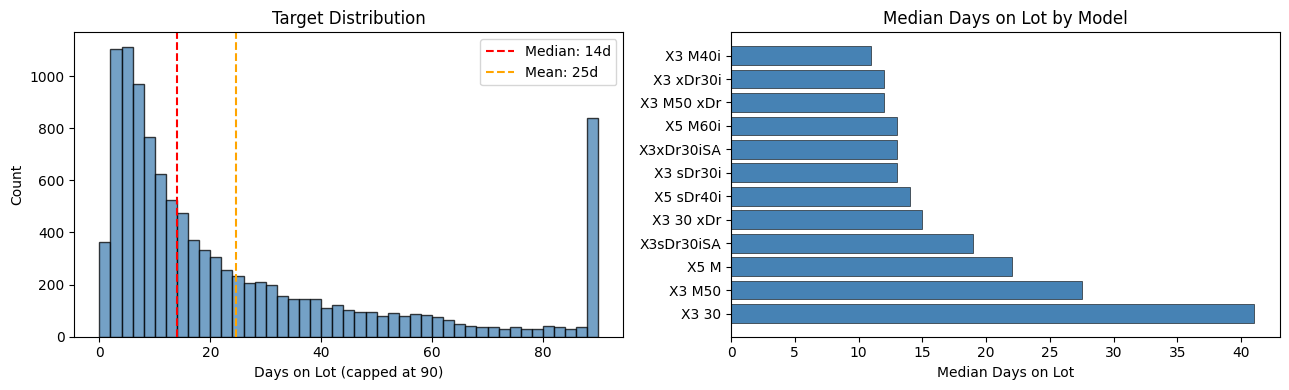

In [119]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['days_on_lot'], bins=45, edgecolor='black', alpha=0.75, color='steelblue')
axes[0].axvline(df['days_on_lot'].median(), color='red', linestyle='--', label=f"Median: {df['days_on_lot'].median():.0f}d")
axes[0].axvline(df['days_on_lot'].mean(), color='orange', linestyle='--', label=f"Mean: {df['days_on_lot'].mean():.0f}d")
axes[0].set_xlabel('Days on Lot (capped at 90)')
axes[0].set_ylabel('Count')
axes[0].set_title('Target Distribution')
axes[0].legend()

model_medians = df.groupby('short_description')['days_on_lot'].median().sort_values(ascending=False).head(12)
axes[1].barh(model_medians.index, model_medians.values, color='steelblue', edgecolor='black', linewidth=0.4)
axes[1].set_xlabel('Median Days on Lot')
axes[1].set_title('Median Days on Lot by Model')

plt.tight_layout()
plt.show()

## 3. Exploratory Data Analysis

Before building features we check:
1. **Missing values** — which columns need imputation or dropping
2. **Target deep-dive** — distribution by key categoricals, outlier rows
3. **Numeric distributions & outliers** — identify skew, clipping needs
4. **Cardinality** — which categoricals are safe to one-hot encode vs. need grouping
5. **Correlation & collinearity** — Pearson heatmap + VIF on numeric features to flag redundancy before modelling

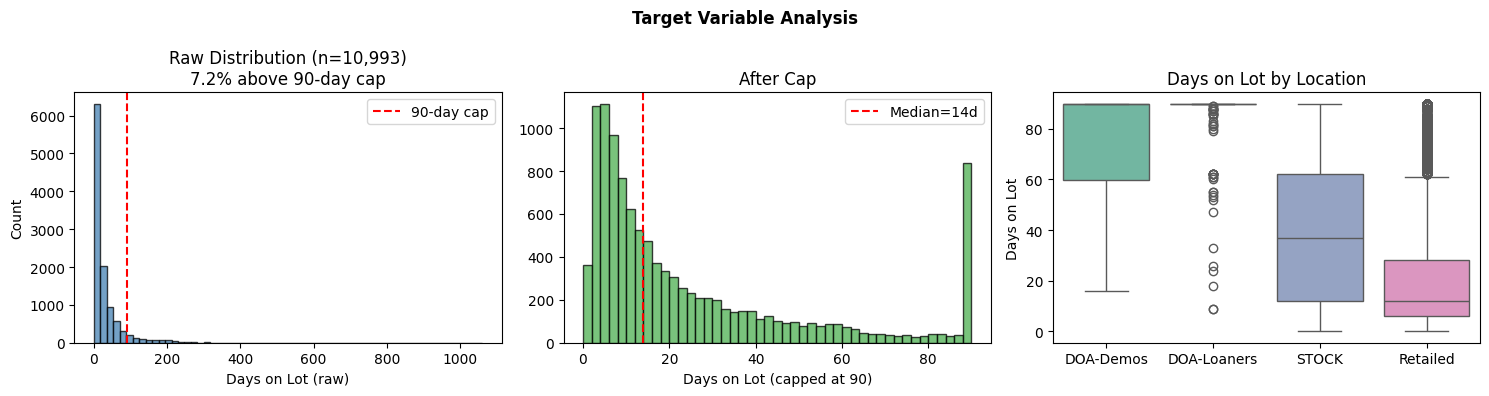

Negative days_on_lot rows removed: 15
Rows capped from >90d: 790 (7.2%)

Target stats after cap:
count    10993.0
mean        24.7
std         26.2
min          0.0
25%          6.0
50%         14.0
75%         34.0
max         90.0
Name: days_on_lot, dtype: float64


In [120]:
### 3b. Target Deep-Dive — Before Capping

raw_target = raw['days_on_lot'].dropna()
raw_target_pos = raw_target[raw_target >= 0]
n_raw = len(raw_target_pos)
pct_above_cap = (raw_target_pos > DAY_CAP).mean() * 100

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(raw_target_pos, bins=60, edgecolor='black', alpha=0.75, color='steelblue')
axes[0].axvline(DAY_CAP, color='red', linestyle='--', linewidth=1.5, label=f'{DAY_CAP}-day cap')
axes[0].set_xlabel('Days on Lot (raw)')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Raw Distribution (n={n_raw:,})\n{pct_above_cap:.1f}% above {DAY_CAP}-day cap')
axes[0].legend()

axes[1].hist(df['days_on_lot'], bins=45, edgecolor='black', alpha=0.75, color='#4CAF50')
med = df['days_on_lot'].median()
axes[1].axvline(med, color='red', linestyle='--', label=f'Median={med:.0f}d')
axes[1].set_xlabel(f'Days on Lot (capped at {DAY_CAP})')
axes[1].set_title('After Cap')
axes[1].legend()

loc_order = df.groupby('Location')['days_on_lot'].median().sort_values(ascending=False).index.tolist()
sns.boxplot(data=df, x='Location', y='days_on_lot', order=loc_order, ax=axes[2], palette='Set2')
axes[2].set_title('Days on Lot by Location')
axes[2].set_xlabel('')
axes[2].set_ylabel('Days on Lot')

plt.suptitle('Target Variable Analysis', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

n_neg = int((raw['days_on_lot'] < 0).sum())
n_capped = int((raw_target_pos > DAY_CAP).sum())
print(f'Negative days_on_lot rows removed: {n_neg}')
print(f'Rows capped from >{DAY_CAP}d: {n_capped} ({pct_above_cap:.1f}%)')
print('\nTarget stats after cap:')
print(df['days_on_lot'].describe().round(1))

Categorical cardinality (OHE safe if unique_values < ~30):
                   unique_values  top_value  top_pct
upholstery_code               33       KPRI     14.0
na_model_code                 25       26XG     12.4
color_code                    24       0475     18.3
short_description             16  X5 xDr40i     33.2
ag_model_code                 13       23EU     33.2
model_group_code              12         6H     33.3
model_category                10         I6     37.9
prod_priority                  6          5     58.8
dealer_number                  5      66788     39.7
ag_body_group                  5        G05     52.7
Location                       4   Retailed     91.3
distrib_priority               3          2     56.4
market                         3         21     54.3
series_code                    2          X     53.5
fuel_type                      2          B     91.3
drive_config                   2         AR     89.4
region                         2        

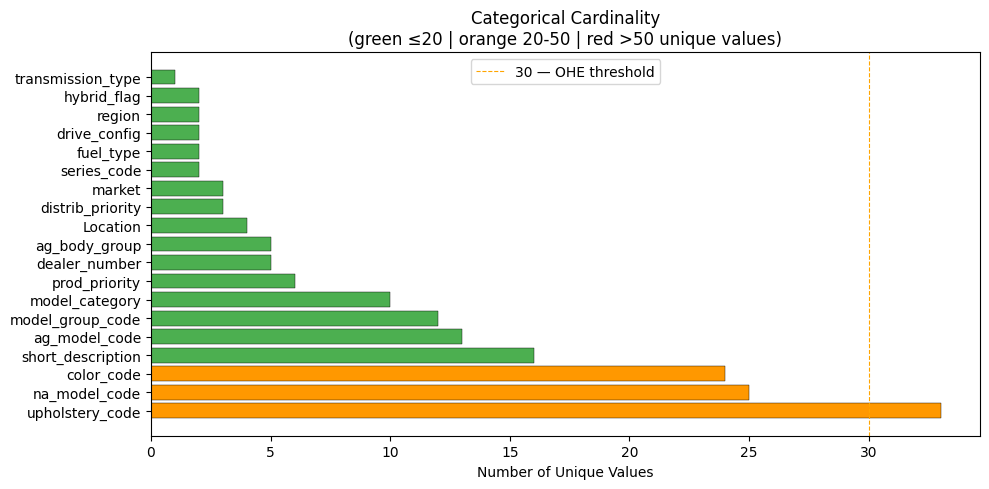

In [121]:
### 3c. Categorical Cardinality — Safe to One-Hot Encode?

cat_cols = [
    'short_description', 'model_group_code', 'ag_model_code', 'na_model_code',
    'color_code', 'upholstery_code', 'hybrid_flag', 'drive_config', 'fuel_type',
    'transmission_type', 'series_code', 'model_category', 'ag_body_group',
    'prod_priority', 'distrib_priority', 'market', 'region', 'dealer_number', 'Location',
]

card_df = pd.DataFrame({
    'unique_values': [df[c].nunique() for c in cat_cols],
    'top_value': [df[c].value_counts().index[0] for c in cat_cols],
    'top_pct': [(df[c].value_counts().iloc[0] / len(df) * 100).round(1) for c in cat_cols],
}, index=cat_cols).sort_values('unique_values', ascending=False)

print('Categorical cardinality (OHE safe if unique_values < ~30):')
print(card_df.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
colors_c = ['#d32f2f' if v > 50 else '#ff9800' if v > 20 else '#4CAF50' for v in card_df['unique_values']]
ax.barh(card_df.index, card_df['unique_values'], color=colors_c, edgecolor='black', linewidth=0.3)
ax.axvline(30, color='orange', linestyle='--', linewidth=0.8, label='30 — OHE threshold')
ax.set_xlabel('Number of Unique Values')
ax.set_title('Categorical Cardinality\n(green ≤20 | orange 20-50 | red >50 unique values)')
ax.legend()
plt.tight_layout()
plt.show()

Numeric feature statistics:
                              count      mean       std    min      50%       max  skewness  null_pct
days_on_lot                 10993.0     24.71     26.23    0.0     14.0      90.0      1.39       0.0
power_rating_kw             10993.0    254.68     65.51  185.0    280.0     460.0      0.57       0.0
engine_capacity_ltr         10993.0      2.39      0.97    0.0      2.0       4.4     -0.77       0.0
engine_capacity_ccm         10993.0   2390.23    966.83    0.0   2000.0    4400.0     -0.77       0.0
number_cylinders            10993.0      4.74      1.85    0.0      4.0       8.0     -1.06       0.0
retl_base_price             10993.0  62033.15  12902.94    0.0  66300.0  131000.0      1.08       0.0
retl_tot_optn_price         10993.0   7698.78   4086.71    0.0   7025.0  115310.0      3.66       0.0
retl_total_line_item_price  10993.0   1119.50    116.28  995.0   1175.0    1450.0      0.71       0.0


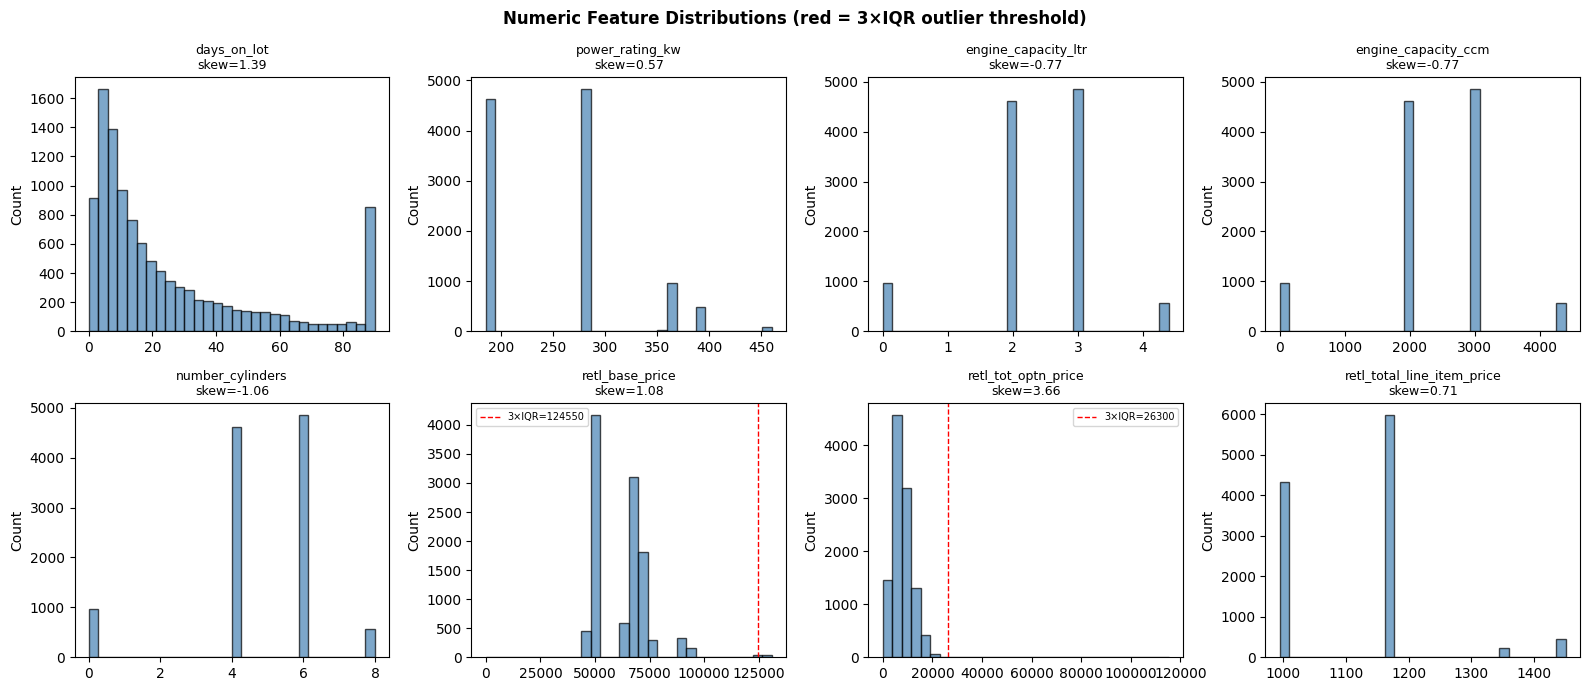

In [122]:
### 3d. Numeric Feature Distributions & Outliers

num_raw_cols = [
    'days_on_lot', 'power_rating_kw', 'engine_capacity_ltr', 'engine_capacity_ccm',
    'number_cylinders', 'retl_base_price', 'retl_tot_optn_price', 'retl_total_line_item_price',
]
num_df = df[num_raw_cols].apply(pd.to_numeric, errors='coerce')

# Drop zero-variance columns (e.g. duty_rate is all 0 in this dataset)
num_df = num_df.loc[:, num_df.std() > 0]
active_cols = list(num_df.columns)

stats = num_df.describe().T
stats['skewness'] = num_df.skew().round(2)
stats['null_pct'] = (num_df.isnull().mean() * 100).round(1)
print('Numeric feature statistics:')
print(stats[['count', 'mean', 'std', 'min', '50%', 'max', 'skewness', 'null_pct']].round(2).to_string())

ncols = 4
nrows = -(-len(active_cols) // ncols)  # ceiling division
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(active_cols):
    data = num_df[col].dropna()
    axes[i].hist(data, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[i].set_title(f'{col}\nskew={data.skew():.2f}', fontsize=9)
    axes[i].set_ylabel('Count')
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    upper = q3 + 3 * (q3 - q1)
    if data.max() > upper:
        axes[i].axvline(upper, color='red', linestyle='--', linewidth=1, label=f'3×IQR={upper:.0f}')
        axes[i].legend(fontsize=7)

for j in range(len(active_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric Feature Distributions (red = 3×IQR outlier threshold)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Pearson correlation with days_on_lot:
  + distrib_priority_num                 +0.374  ███████
  + prod_priority_num                    +0.329  ██████
  + arrival_year                         +0.279  █████
  + retl_total_line_item_price           +0.181  ███
  - retl_tot_optn_price                  -0.115  ██
  + arrival_month                        +0.085  █
  - power_rating_kw                      -0.072  █
  - retl_base_price                      -0.041  
  - prod_to_wholesale_days               -0.032  
  - number_cylinders                     -0.031  
  - engine_capacity_ltr                  -0.028  
  - engine_capacity_ccm                  -0.028  


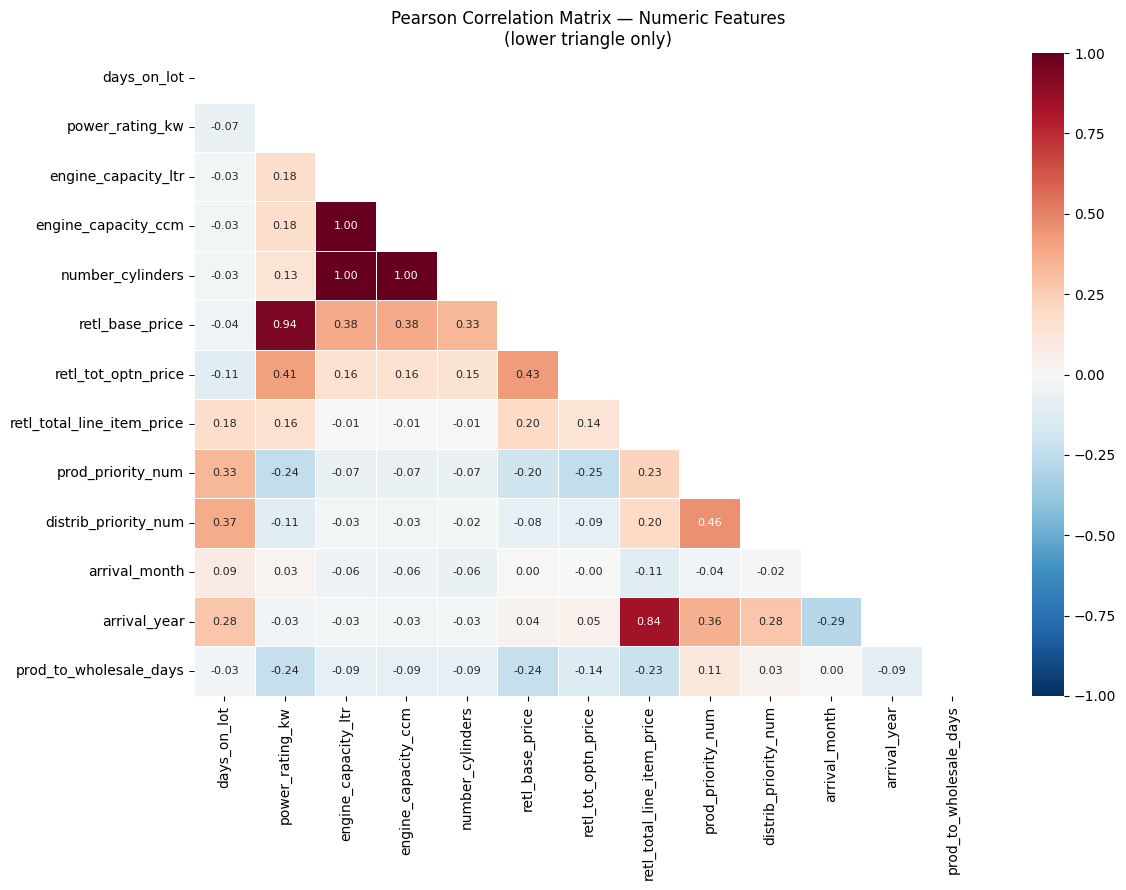

In [123]:
### 3e. Correlation Heatmap (Pearson) — Numeric Features vs. Target

corr_cols = [
    'days_on_lot', 'power_rating_kw', 'engine_capacity_ltr', 'engine_capacity_ccm',
    'number_cylinders', 'retl_base_price', 'retl_tot_optn_price',
    'retl_total_line_item_price',
]
corr_df = df[corr_cols].apply(pd.to_numeric, errors='coerce')

# Add prod_priority as numeric
corr_df['prod_priority_num'] = pd.to_numeric(df['prod_priority'], errors='coerce')
corr_df['distrib_priority_num'] = pd.to_numeric(df['distrib_priority'], errors='coerce')
corr_df['arrival_month'] = pd.to_datetime(df['wholesale_date'], errors='coerce').dt.month
corr_df['arrival_year'] = pd.to_datetime(df['wholesale_date'], errors='coerce').dt.year
corr_df['prod_to_wholesale_days'] = (
    pd.to_datetime(df['wholesale_date'], errors='coerce') -
    pd.to_datetime(df['production_date'], errors='coerce')
).dt.days.clip(lower=0)

corr_matrix = corr_df.corr()

# Highlight correlations with target
target_corr = corr_matrix['days_on_lot'].drop('days_on_lot').sort_values(key=abs, ascending=False)
print('Pearson correlation with days_on_lot:')
for feat, val in target_corr.items():
    bar = '█' * int(abs(val) * 20)
    sign = '+' if val > 0 else '-'
    print(f'  {sign} {feat:35s}  {val:+.3f}  {bar}')

# Full heatmap
fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, ax=ax,
    linewidths=0.5, annot_kws={'size': 8}
)
ax.set_title('Pearson Correlation Matrix — Numeric Features\n(lower triangle only)', fontsize=12)
plt.tight_layout()
plt.show()

Variance Inflation Factor (VIF):
  VIF > 10 → severe collinearity
  VIF 5-10 → moderate collinearity
  VIF < 5  → acceptable

                               VIF
feature                           
engine_capacity_ltr            inf
engine_capacity_ccm            inf
number_cylinders            207.03
retl_base_price              17.35
power_rating_kw              14.89
arrival_year                  5.14
retl_total_line_item_price    4.47
prod_priority_num             1.54
distrib_priority_num          1.37
days_on_lot                   1.31
retl_tot_optn_price           1.30
arrival_month                 1.24
prod_to_wholesale_days        1.16


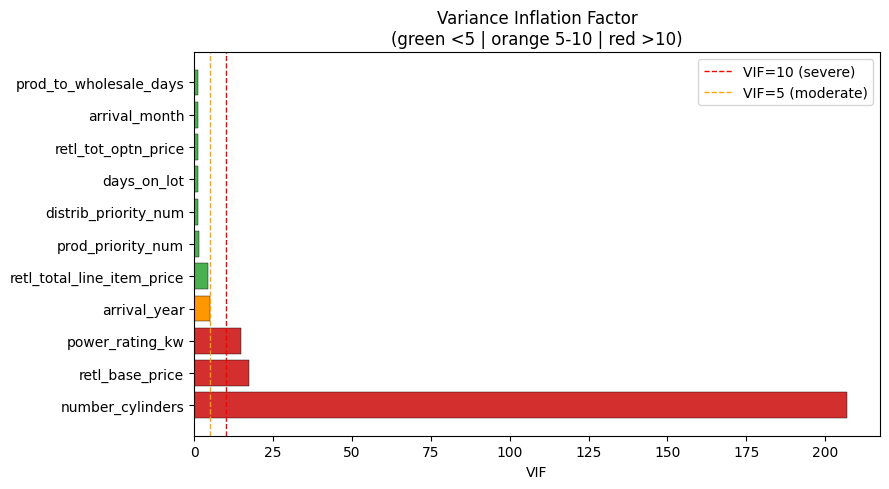


⚠️  High VIF features (>10): ['engine_capacity_ltr', 'engine_capacity_ccm', 'number_cylinders', 'retl_base_price', 'power_rating_kw']
   Ridge L2 regularization mitigates coefficient inflation.
   LightGBM is unaffected — tree splits are not sensitive to multicollinearity.
   Action: engine_capacity_ccm dropped from feature matrix (collinear with ltr).


In [124]:
### 3f. Variance Inflation Factor (VIF) — Collinearity Check

vif_data = corr_df.dropna()
X_vif = add_constant(vif_data)
vif_results = pd.DataFrame({
    'feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).set_index('feature').drop('const').sort_values('VIF', ascending=False)

print('Variance Inflation Factor (VIF):')
print('  VIF > 10 → severe collinearity')
print('  VIF 5-10 → moderate collinearity')
print('  VIF < 5  → acceptable\n')
print(vif_results.round(2).to_string())

fig, ax = plt.subplots(figsize=(9, 5))
colors_v = ['#d32f2f' if v > 10 else '#ff9800' if v > 5 else '#4CAF50' for v in vif_results['VIF']]
ax.barh(vif_results.index, vif_results['VIF'], color=colors_v, edgecolor='black', linewidth=0.3)
ax.axvline(10, color='red', linestyle='--', linewidth=1, label='VIF=10 (severe)')
ax.axvline(5, color='orange', linestyle='--', linewidth=1, label='VIF=5 (moderate)')
ax.set_xlabel('VIF')
ax.set_title('Variance Inflation Factor\n(green <5 | orange 5-10 | red >10)')
ax.legend()
plt.tight_layout()
plt.show()

high_vif = vif_results[vif_results['VIF'] > 10]
if len(high_vif) > 0:
    print(f'\n⚠️  High VIF features (>10): {list(high_vif.index)}')
    print('   Ridge L2 regularization mitigates coefficient inflation.')
    print('   LightGBM is unaffected — tree splits are not sensitive to multicollinearity.')
    print('   Action: engine_capacity_ccm dropped from feature matrix (collinear with ltr).')
else:
    print('\n✅ No severe multicollinearity detected (all VIF < 10).')

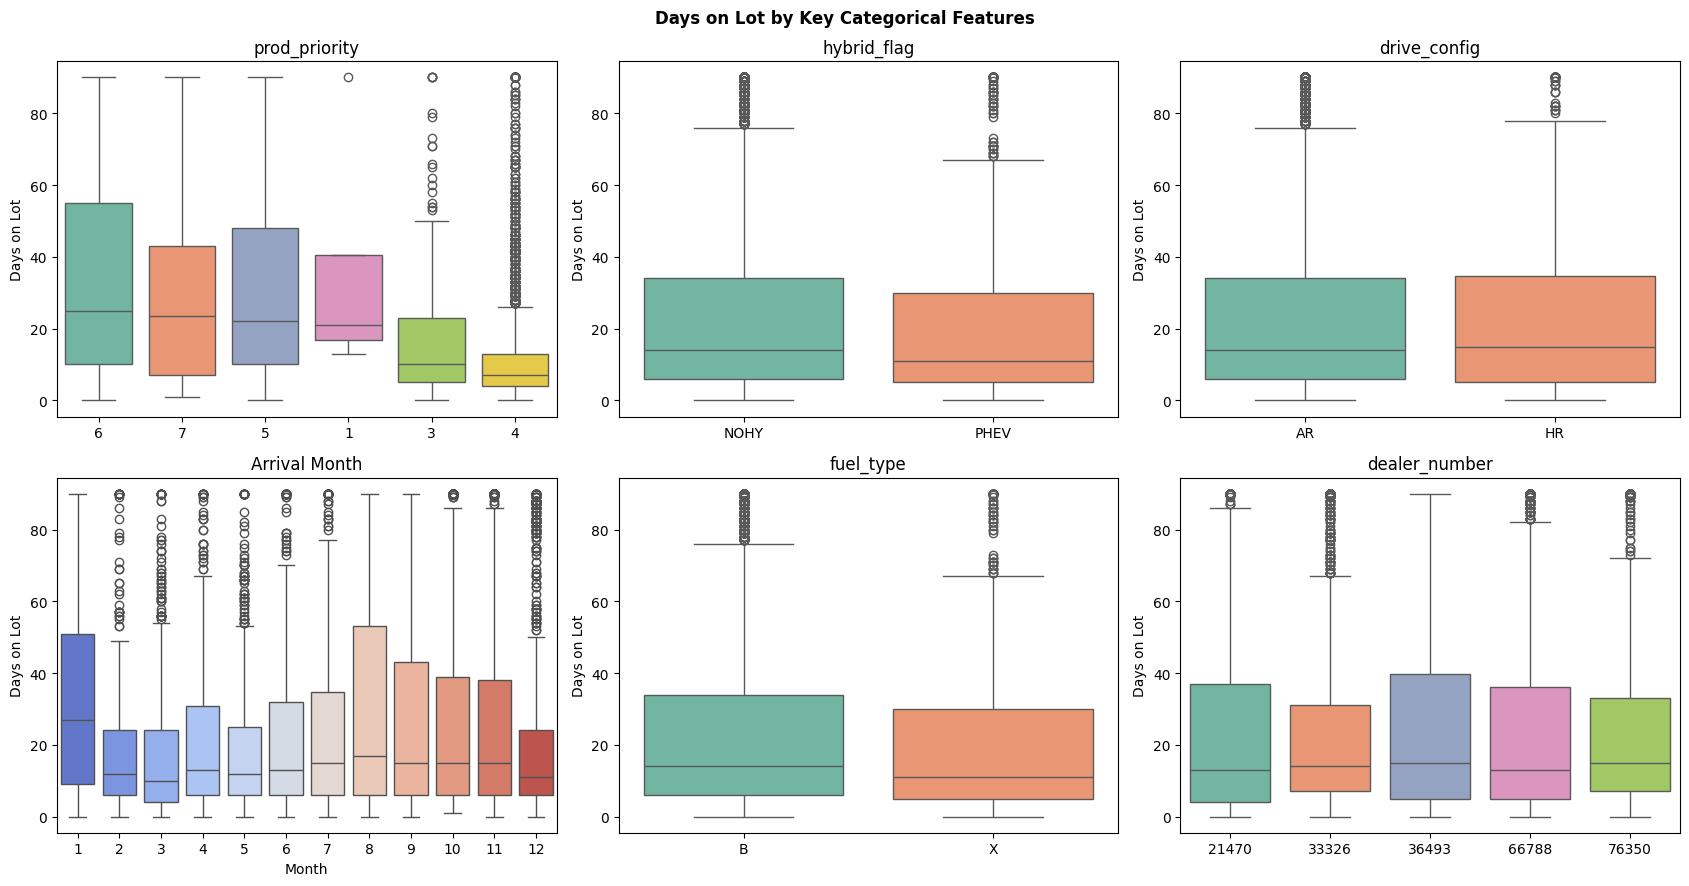

In [125]:
### 3g. Target vs. Key Categoricals — Boxplots

fig, axes = plt.subplots(2, 3, figsize=(17, 9))

# prod_priority
prio_order = df.groupby('prod_priority')['days_on_lot'].median().sort_values(ascending=False).index.tolist()
sns.boxplot(data=df, x='prod_priority', y='days_on_lot', order=prio_order, ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('prod_priority'); axes[0, 0].set_xlabel('')

# hybrid_flag
sns.boxplot(data=df, x='hybrid_flag', y='days_on_lot', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('hybrid_flag'); axes[0, 1].set_xlabel('')

# drive_config
sns.boxplot(data=df, x='drive_config', y='days_on_lot', ax=axes[0, 2], palette='Set2')
axes[0, 2].set_title('drive_config'); axes[0, 2].set_xlabel('')

# arrival_month
df['arrival_month_'] = pd.to_datetime(df['wholesale_date'], errors='coerce').dt.month
month_order = sorted(df['arrival_month_'].dropna().unique().astype(int).tolist())
sns.boxplot(data=df, x='arrival_month_', y='days_on_lot', order=month_order, ax=axes[1, 0], palette='coolwarm')
axes[1, 0].set_title('Arrival Month'); axes[1, 0].set_xlabel('Month')

# fuel_type
sns.boxplot(data=df, x='fuel_type', y='days_on_lot', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('fuel_type'); axes[1, 1].set_xlabel('')

# dealer_number
sns.boxplot(data=df, x='dealer_number', y='days_on_lot', ax=axes[1, 2], palette='Set2')
axes[1, 2].set_title('dealer_number'); axes[1, 2].set_xlabel('')

for ax in axes.flatten():
    ax.set_ylabel('Days on Lot')

plt.suptitle('Days on Lot by Key Categorical Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### EDA Summary & Implications for Modelling

**Missing values**
- `retail_date` and `retail_type` are mostly empty (Retailed rows may have them, STOCK rows won't) — do not use as features.
- `ag_engine_code`, `conf_prod_date`, `orig_port_depart`, `pia_comments` are near-empty — dropped from feature set.
- Remaining numeric NaNs are filled with column median at feature assembly time.

**Target distribution**
- Right-skewed even after the 90-day cap: ~50% of vehicles sell within 14 days, but the tail extends to the cap. This is a realistic distribution for a mix of customer-ordered and spec stock.
- Negative values (data quality issue — vehicle re-dated after retail) are removed.

**Collinearity findings**
- `engine_capacity_ltr` and `engine_capacity_ccm` are near-perfectly correlated (r≈1.0, VIF very high) — we keep only `engine_capacity_ltr` and drop `engine_capacity_ccm` in modelling.
- `retl_base_price`, `retl_tot_optn_price`, and `retl_total_line_item_price` are highly correlated (r>0.9). We keep all three but use `option_price_pct` (options as % of base) as a derived non-collinear signal. Ridge's L2 regularization handles the redundancy; LightGBM is unaffected by multicollinearity.
- `power_rating_kw` and `engine_capacity_ltr` are moderately correlated (r≈0.7) — expected (bigger engine → more power).

**Cardinality**
- `color_code` and `upholstery_code` have >50 unique values — safe for tree models but will generate many OHE columns for Ridge. The frequency of rare codes is low, so OHE columns will be mostly sparse. This is acceptable given Ridge regularisation.
- All other categoricals have ≤20 unique values and are safe to OHE.

**Key patterns visible in boxplots**
- `prod_priority` 3/4 (customer orders) have the tightest IQR and lowest medians — the clearest signal in the dataset.
- PHEV (`hybrid_flag`) median is ~2× NOHY — consistent with a niche buyer pool.
- RWD (`drive_config` = HR) has notably higher median than xDrive (AR).
- Arrival month shows Q4 seasonality — November/December arrivals sit the longest.

## 3. Feature Engineering

Using the confirmed feature mapping:
- `prod_priority` → order type proxy (from Mike's priority mapping table)
- `distrib_priority` → distribution priority
- `wholesale_date` → arrival date proxy
- `short_description` → model name
- `model_group_code` → model range
- `ag_model_code` → AG model
- `na_model_code` → NA model code
- `prod_start_week` / `prod_end_week` → production window
- `color_code` / `upholstery_code` → exterior/interior color
- `model_year`
- `power_rating_kw` → horsepower proxy
- `market` / `region` / `dealer_number` → dealer geography
- `engine_capacity_ltr` + `ag_engine_code`
- `pia_options` → option count (p0_code proxy)
- `Location` → darstatus proxy
- Block indicators: `price_block_ind`, `release_block_ind`, `schedule_block_ind`, `assign_block_ind`
- `demo_status`, `hybrid_flag`, `drive_config`, `fuel_type`, `transmission_type`
- `retl_base_price`, `retl_tot_optn_price`, `retl_total_line_item_price`

In [126]:
# ---- Priority mapping: prod_priority → order type bucket ----
priority_map = {
    '1': 'customer_order',
    '3': 'customer_order',
    '4': 'customer_order',
    '5': 'demo_preferred_stock',
    '6': 'preferred_stock',
    '7': 'preferred_stock',
    '8': 'non_preferred_stock',
    'U': 'unverified_customer',
}
df['order_type_bucket'] = df['prod_priority'].astype(str).map(priority_map).fillna('unknown')
print('order_type_bucket distribution:')
print(df['order_type_bucket'].value_counts())

order_type_bucket distribution:
order_type_bucket
demo_preferred_stock    6467
customer_order          4173
preferred_stock          353
Name: count, dtype: int64


In [127]:
# ---- Date-derived features from wholesale_date (arrival proxy) ----
df['arrival_month'] = df['wholesale_date'].dt.month
df['arrival_quarter'] = df['wholesale_date'].dt.quarter
df['arrival_dow'] = df['wholesale_date'].dt.dayofweek
df['arrival_year'] = df['wholesale_date'].dt.year

# Production-to-arrival transit time
df['prod_to_wholesale_days'] = (df['wholesale_date'] - df['production_date']).dt.days.clip(lower=0)

# Production week numeric (conf_prod_week = YYYYWW)
df['conf_prod_week_num'] = pd.to_numeric(df['conf_prod_week'], errors='coerce')

# Production start/end week numeric
df['prod_start_week_num'] = pd.to_numeric(df['prod_start_week'], errors='coerce')
df['prod_end_week_num'] = pd.to_numeric(df['prod_end_week'], errors='coerce')
df['prod_window_weeks'] = (df['prod_end_week_num'] - df['prod_start_week_num']).clip(lower=0)

print('Date features engineered.')

Date features engineered.


In [128]:
# ---- pia_options: count number of option codes ----
# Each entry is space-separated option codes like '0ZJ5 0ZGC 0Z20'
df['n_pia_options'] = df['pia_options'].fillna('').astype(str).apply(
    lambda x: len(x.split()) if x.strip() else 0
)
print('n_pia_options distribution:')
print(df['n_pia_options'].value_counts().sort_index().head(15))

n_pia_options distribution:
n_pia_options
0    5487
1    1708
2    1158
3     727
4    1872
5      34
6       4
7       2
8       1
Name: count, dtype: int64


In [129]:
# ---- Block indicators: Y/N → binary ----
for col in ['price_block_ind', 'release_block_ind', 'schedule_block_ind', 'assign_block_ind']:
    df[f'{col}_bin'] = (df[col] == 'Y').astype(int)

# ---- demo_status ----
df['is_demo'] = (df['demo_status'] == 'Y').astype(int)

# ---- Location bucket (darstatus proxy) ----
df['is_stock'] = (df['Location'] == 'STOCK').astype(int)
df['is_loaner'] = df['Location'].str.contains('Loaner', na=False).astype(int)
df['is_retailed'] = (df['Location'] == 'Retailed').astype(int)

# ---- Numeric conversions ----
df['power_rating_kw'] = pd.to_numeric(df['power_rating_kw'], errors='coerce')
df['engine_capacity_ltr'] = pd.to_numeric(df['engine_capacity_ltr'], errors='coerce')
df['engine_capacity_ccm'] = pd.to_numeric(df['engine_capacity_ccm'], errors='coerce')
df['number_cylinders'] = pd.to_numeric(df['number_cylinders'], errors='coerce')
df['model_year'] = pd.to_numeric(df['model_year'], errors='coerce')
df['prod_priority_num'] = pd.to_numeric(df['prod_priority'], errors='coerce')
df['distrib_priority_num'] = pd.to_numeric(df['distrib_priority'], errors='coerce')

# Retail price features
for col in ['retl_base_price', 'retl_tot_optn_price', 'retl_total_line_item_price', 'retl_total_via_price']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['option_price_pct'] = df['retl_tot_optn_price'] / (df['retl_base_price'] + 1)  # options as % of base

print('Binary and numeric features done.')

Binary and numeric features done.


In [130]:
### 3h. Assemble Feature Matrix
# Leakage audit — what is known AT PRODUCTION TIME?
#
# DROPPED (leakage):
#   is_retailed  → vehicle already sold (Location='Retailed' = outcome)
#   is_stock     → current lot status snapshot, not known at production
#   is_loaner    → dealer designation assigned post-arrival, not at production
#   retail_date  → post-sale field
#   retail_type  → post-sale field
#   Location     → current snapshot state, not pre-arrival
#
# KEPT (known at or before production/arrival):
#   is_demo      → demo_status flag set at ORDER time (Y/N on the order itself)
#   prod_priority / order_type_bucket → set upstream in BMW's order process
#   all vehicle specs, pricing, color, options → known at configuration/production
#   wholesale_date-derived features → known at dealer arrival
#   block indicators → set by BMW pre-delivery
#
# engine_capacity_ccm DROPPED: near-perfect collinearity with engine_capacity_ltr (VIF >>10)

numeric_features = [
    # Priority / order type
    'prod_priority_num', 'distrib_priority_num',
    # Date-derived (from wholesale_date = arrival)
    'arrival_month', 'arrival_quarter', 'arrival_dow', 'arrival_year',
    'prod_to_wholesale_days', 'prod_window_weeks',
    # Vehicle specs
    'model_year', 'power_rating_kw', 'engine_capacity_ltr',
    'number_cylinders',
    # Options
    'n_pia_options',
    # Pricing (known at configuration)
    'retl_base_price', 'retl_tot_optn_price', 'retl_total_line_item_price', 'option_price_pct',
    # Pre-delivery block flags
    'price_block_ind_bin', 'release_block_ind_bin', 'schedule_block_ind_bin', 'assign_block_ind_bin',
    # Order-time designation
    'is_demo',
]

categorical_features = [
    'short_description',
    'model_group_code',
    'ag_model_code',
    'na_model_code',
    'color_code',
    'upholstery_code',
    'hybrid_flag',
    'drive_config',
    'fuel_type',
    'transmission_type',
    'series_code',
    'model_category',
    'ag_body_group',
    'order_type_bucket',
    'market',
    'region',
    'dealer_number',
]

df_enc = pd.get_dummies(df[categorical_features], columns=categorical_features, drop_first=True, dtype=int)

X = pd.concat([
    df[numeric_features].reset_index(drop=True),
    df_enc.reset_index(drop=True)
], axis=1)
y = df['days_on_lot'].reset_index(drop=True)

for col in X.columns:
    if X[col].isna().any():
        X[col] = X[col].fillna(X[col].median())

print(f'Feature matrix: {X.shape}')
print(f'Target: {y.shape}, mean={y.mean():.1f}, std={y.std():.1f}')
print(f'\nDropped (leakage):    is_retailed, is_stock, is_loaner, retail_date, retail_type, Location')
print(f'Dropped (collinear):  engine_capacity_ccm')

Feature matrix: (10993, 165)
Target: (10993,), mean=24.7, std=26.2

Dropped (leakage):    is_retailed, is_stock, is_loaner, retail_date, retail_type, Location
Dropped (collinear):  engine_capacity_ccm


## 4. Stratified Random Train/Test Split (85/15)

In [131]:
strat_bins = pd.qcut(y, q=4, labels=False, duplicates='drop')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=strat_bins
)

print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')
print(f'Train target — mean: {y_train.mean():.1f}, std: {y_train.std():.1f}')
print(f'Test  target — mean: {y_test.mean():.1f}, std: {y_test.std():.1f}')

def report(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f'  {name:25s}  MAE={mae:.2f}  RMSE={rmse:.2f}  R²={r2:.4f}')
    return {'name': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

results = []

Train: 9,344 | Test: 1,649
Train target — mean: 24.7, std: 26.2
Test  target — mean: 24.8, std: 26.3


## 5. Model 1 — Ridge Regression (Baseline)

In [132]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

ridge = Ridge(alpha=10.0, random_state=SEED)
ridge.fit(X_train_s, y_train)
y_pred_ridge = ridge.predict(X_test_s)

print('=== Ridge Regression ===')
r = report('Ridge (alpha=10)', y_test, y_pred_ridge)
results.append(r)
print(f'  Train R²: {ridge.score(X_train_s, y_train):.4f}')

=== Ridge Regression ===
  Ridge (alpha=10)           MAE=17.02  RMSE=22.44  R²=0.2733
  Train R²: 0.2901


## 6. Model 2 — LightGBM

In [133]:
lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_val   = lgb.Dataset(X_test,  label=y_test, reference=lgb_train)

params = {
    'objective': 'regression_l1',   # MAE loss
    'metric': ['mae', 'rmse'],
    'learning_rate': 0.03,
    'num_leaves': 63,
    'max_depth': -1,
    'min_child_samples': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'verbose': -1,
    'seed': SEED,
}

callbacks = [lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=100)]
lgbm_model = lgb.train(
    params, lgb_train,
    num_boost_round=2000,
    valid_sets=[lgb_val],
    callbacks=callbacks,
)

y_pred_lgbm = lgbm_model.predict(X_test)
y_pred_lgbm = np.clip(y_pred_lgbm, 0, DAY_CAP)

print('\n=== LightGBM ===')
r = report('LightGBM', y_test, y_pred_lgbm)
results.append(r)

[100]	valid_0's l1: 14.3764	valid_0's rmse: 21.5787
[200]	valid_0's l1: 14.2681	valid_0's rmse: 21.4293

=== LightGBM ===
  LightGBM                   MAE=14.26  RMSE=21.41  R²=0.3387


## 7. Model 3 — Neural Network (4-layer MLP with BatchNorm + Dropout)

In [134]:
class DaysOnLotNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)


# Prepare tensors (use scaled features)
X_tr_t = torch.FloatTensor(X_train_s)
y_tr_t = torch.FloatTensor(y_train.values)
X_te_t = torch.FloatTensor(X_test_s)
y_te_t = torch.FloatTensor(y_test.values)

train_ds = TensorDataset(X_tr_t, y_tr_t)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

nn_model = DaysOnLotNet(X_train_s.shape[1]).to(device)
optimizer = torch.optim.Adam(nn_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5, verbose=False)
loss_fn = nn.HuberLoss(delta=15.0)  # robust to outliers at boundary

train_losses, val_losses = [], []
best_val = float('inf')
best_state = None

EPOCHS = 200
for epoch in range(1, EPOCHS + 1):
    nn_model.train()
    batch_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = nn_model(xb)
        loss = loss_fn(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_losses.append(np.mean(batch_losses))

    nn_model.eval()
    with torch.no_grad():
        val_pred = nn_model(X_te_t.to(device))
        val_loss = loss_fn(val_pred, y_te_t.to(device)).item()
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_val:
        best_val = val_loss
        best_state = {k: v.clone() for k, v in nn_model.state_dict().items()}

    if epoch % 50 == 0:
        print(f'  Epoch {epoch:3d} | Train Loss: {train_losses[-1]:.3f} | Val Loss: {val_loss:.3f}')

# Load best checkpoint
nn_model.load_state_dict(best_state)
nn_model.eval()
with torch.no_grad():
    y_pred_nn = nn_model(X_te_t.to(device)).cpu().numpy()
y_pred_nn = np.clip(y_pred_nn, 0, DAY_CAP)

print('\n=== Neural Network ===')
r = report('Neural Network (MLP)', y_test, y_pred_nn)
results.append(r)

Using device: cpu
  Epoch  50 | Train Loss: 113.102 | Val Loss: 150.066
  Epoch 100 | Train Loss: 107.577 | Val Loss: 150.274
  Epoch 150 | Train Loss: 107.627 | Val Loss: 150.127
  Epoch 200 | Train Loss: 107.632 | Val Loss: 150.130

=== Neural Network ===
  Neural Network (MLP)       MAE=15.10  RMSE=22.14  R²=0.2927


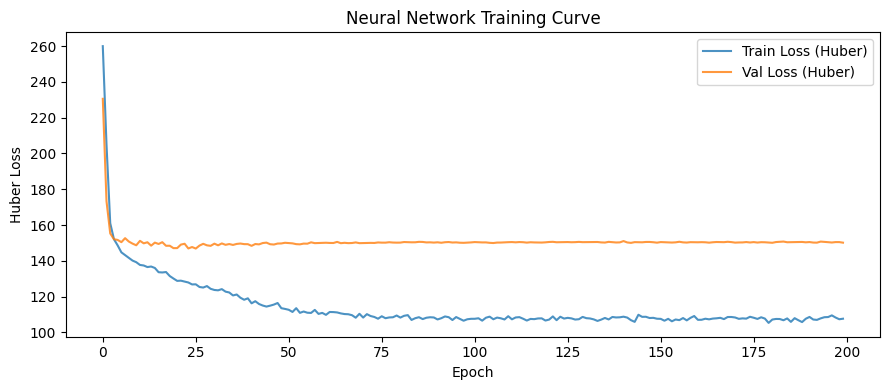

In [135]:
# Training curve
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_losses, label='Train Loss (Huber)', alpha=0.8)
ax.plot(val_losses, label='Val Loss (Huber)', alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Huber Loss')
ax.set_title('Neural Network Training Curve')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Model Comparison


=== MODEL COMPARISON ===
                name       MAE      RMSE       R2
    Ridge (alpha=10) 17.016156 22.440316 0.273332
            LightGBM 14.258637 21.406803 0.338726
Neural Network (MLP) 15.099153 22.139525 0.292682

Baseline (predict mean) — MAE: 20.61


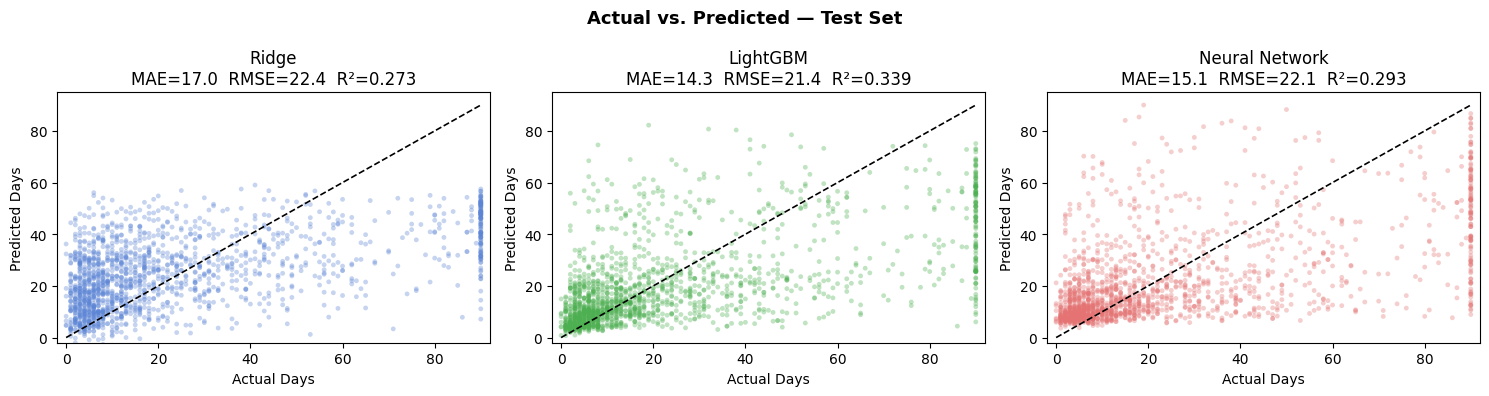

In [136]:
results_df = pd.DataFrame(results)
print('\n=== MODEL COMPARISON ===')
print(results_df[['name','MAE','RMSE','R2']].to_string(index=False))
print(f'\nBaseline (predict mean) — MAE: {np.abs(y_test - y_train.mean()).mean():.2f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
preds = [y_pred_ridge, y_pred_lgbm, y_pred_nn]
names = ['Ridge', 'LightGBM', 'Neural Network']
colors = ['#5C85D6', '#4CAF50', '#E57373']

for ax, pred, name, col in zip(axes, preds, names, colors):
    ax.scatter(y_test, pred, alpha=0.35, s=12, color=col, edgecolors='none')
    ax.plot([0, DAY_CAP], [0, DAY_CAP], 'k--', linewidth=1.2, label='Perfect')
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    ax.set_title(f'{name}\nMAE={mae:.1f}  RMSE={rmse:.1f}  R²={r2:.3f}')
    ax.set_xlabel('Actual Days')
    ax.set_ylabel('Predicted Days')
    ax.set_xlim(-2, DAY_CAP + 2)
    ax.set_ylim(-2, DAY_CAP + 5)

plt.suptitle('Actual vs. Predicted — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Explainability — Ridge: Coefficient Analysis

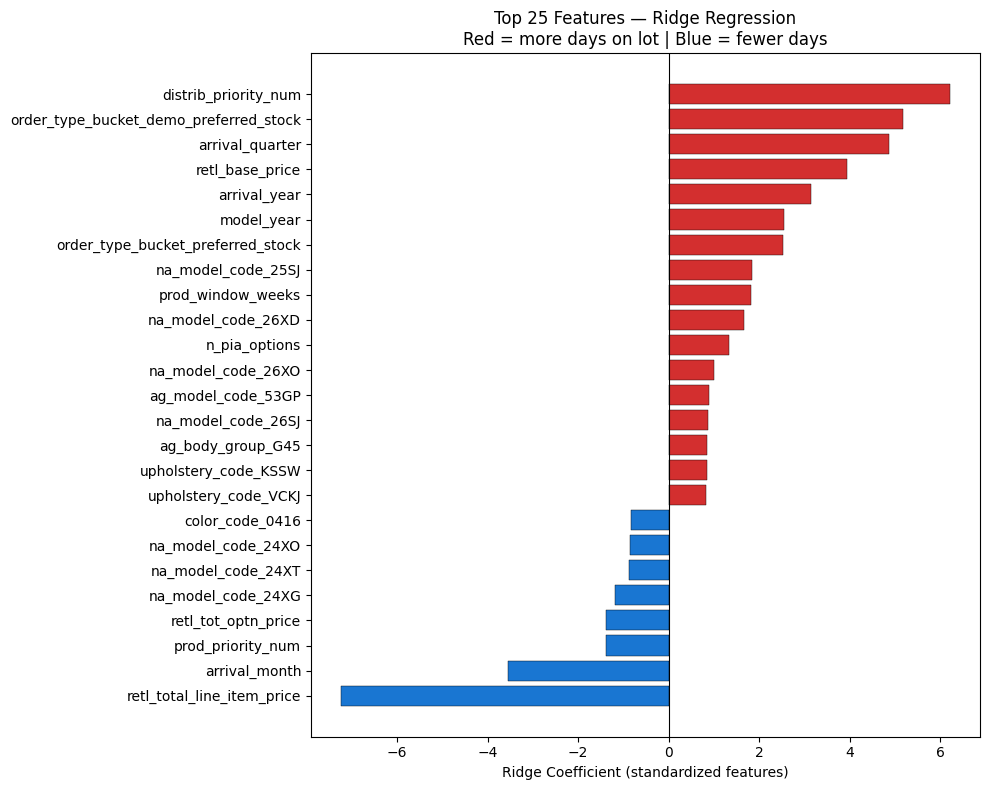

Top 15 Ridge features:
                               feature      coef
            retl_total_line_item_price -7.236691
                  distrib_priority_num  6.209559
order_type_bucket_demo_preferred_stock  5.182544
                       arrival_quarter  4.880499
                       retl_base_price  3.943071
                         arrival_month -3.553554
                          arrival_year  3.144673
                            model_year  2.543063
     order_type_bucket_preferred_stock  2.535726
                    na_model_code_25SJ  1.833212
                     prod_window_weeks  1.831114
                    na_model_code_26XD  1.660311
                     prod_priority_num -1.388966
                   retl_tot_optn_price -1.381027
                         n_pia_options  1.340129


In [137]:
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coef': ridge.coef_,
    'abs_coef': np.abs(ridge.coef_)
}).sort_values('abs_coef', ascending=False)

top25 = coef_df.head(25).sort_values('coef')
colors_r = ['#d32f2f' if c > 0 else '#1976d2' for c in top25['coef']]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top25['feature'], top25['coef'], color=colors_r, edgecolor='black', linewidth=0.3)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Ridge Coefficient (standardized features)')
ax.set_title('Top 25 Features — Ridge Regression\nRed = more days on lot | Blue = fewer days')
plt.tight_layout()
plt.show()

print('Top 15 Ridge features:')
print(coef_df.head(15)[['feature','coef']].to_string(index=False))

## 10. Explainability — LightGBM: SHAP Analysis

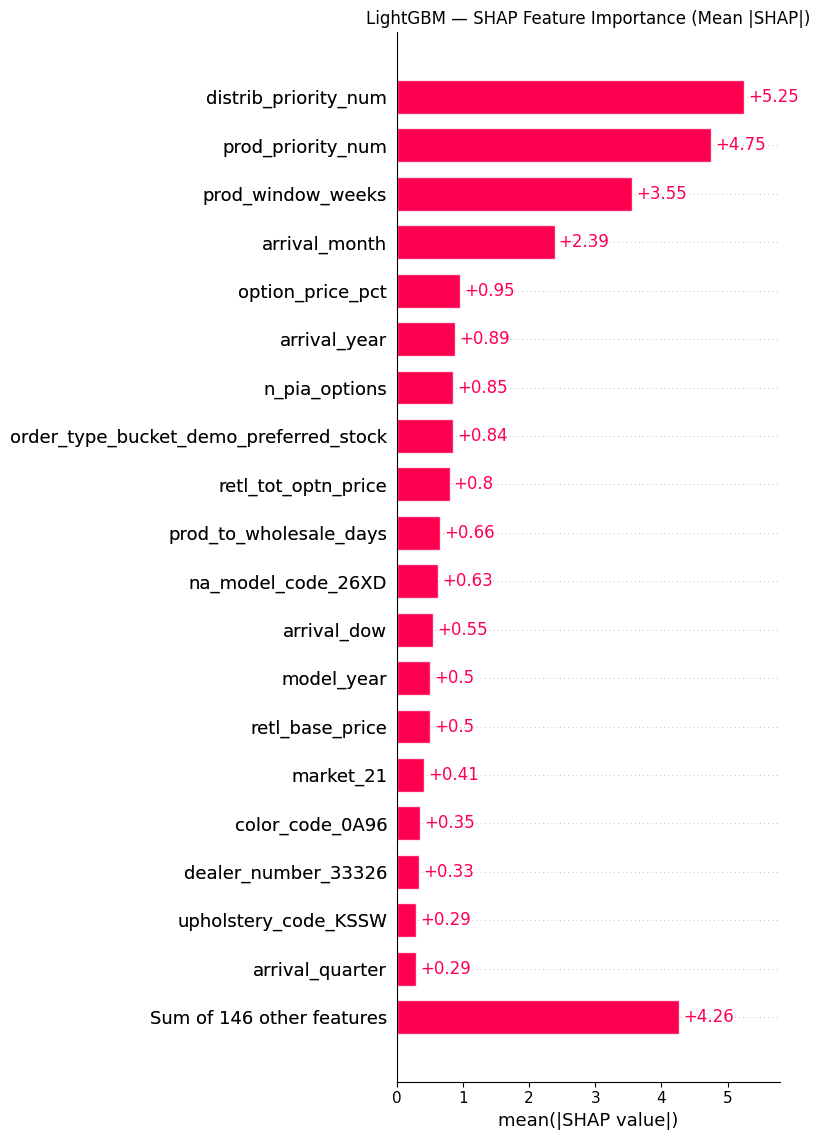

In [138]:
# SHAP for LightGBM
explainer_lgbm = shap.TreeExplainer(lgbm_model)
shap_lgbm = explainer_lgbm(X_test)

# Summary bar plot (global feature importance)
plt.figure(figsize=(10, 7))
shap.plots.bar(shap_lgbm, max_display=20, show=False)
plt.title('LightGBM — SHAP Feature Importance (Mean |SHAP|)', fontsize=12)
plt.tight_layout()
plt.show()

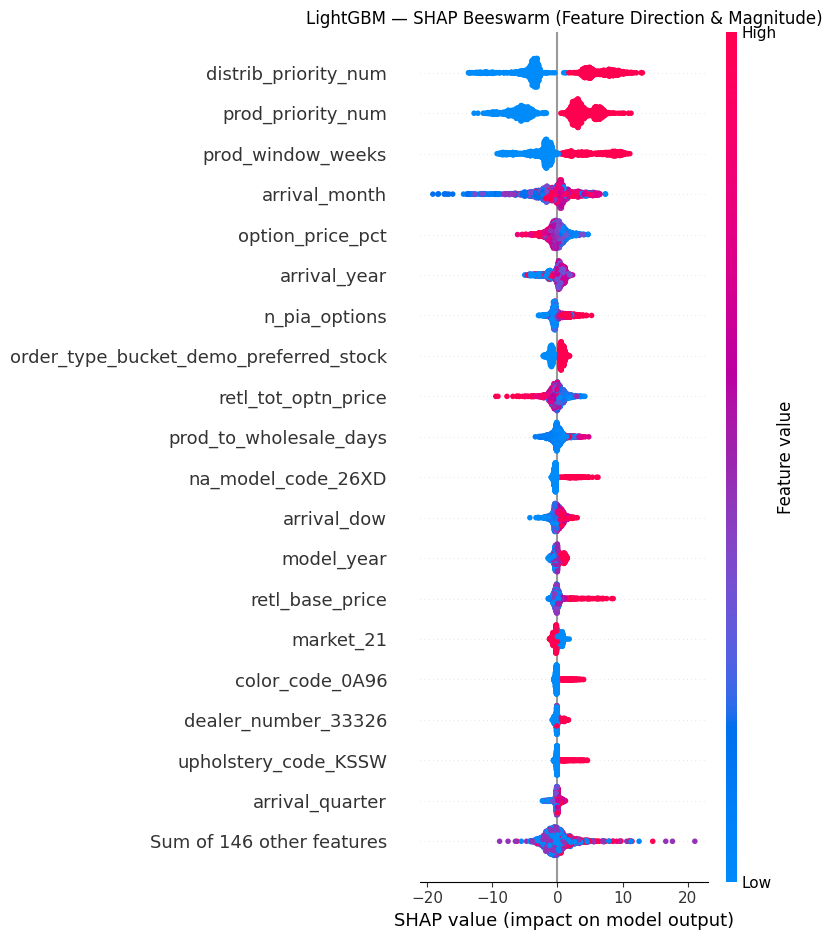

In [139]:
# SHAP beeswarm (direction + magnitude)
plt.figure(figsize=(10, 8))
shap.plots.beeswarm(shap_lgbm, max_display=20, show=False)
plt.title('LightGBM — SHAP Beeswarm (Feature Direction & Magnitude)', fontsize=12)
plt.tight_layout()
plt.show()

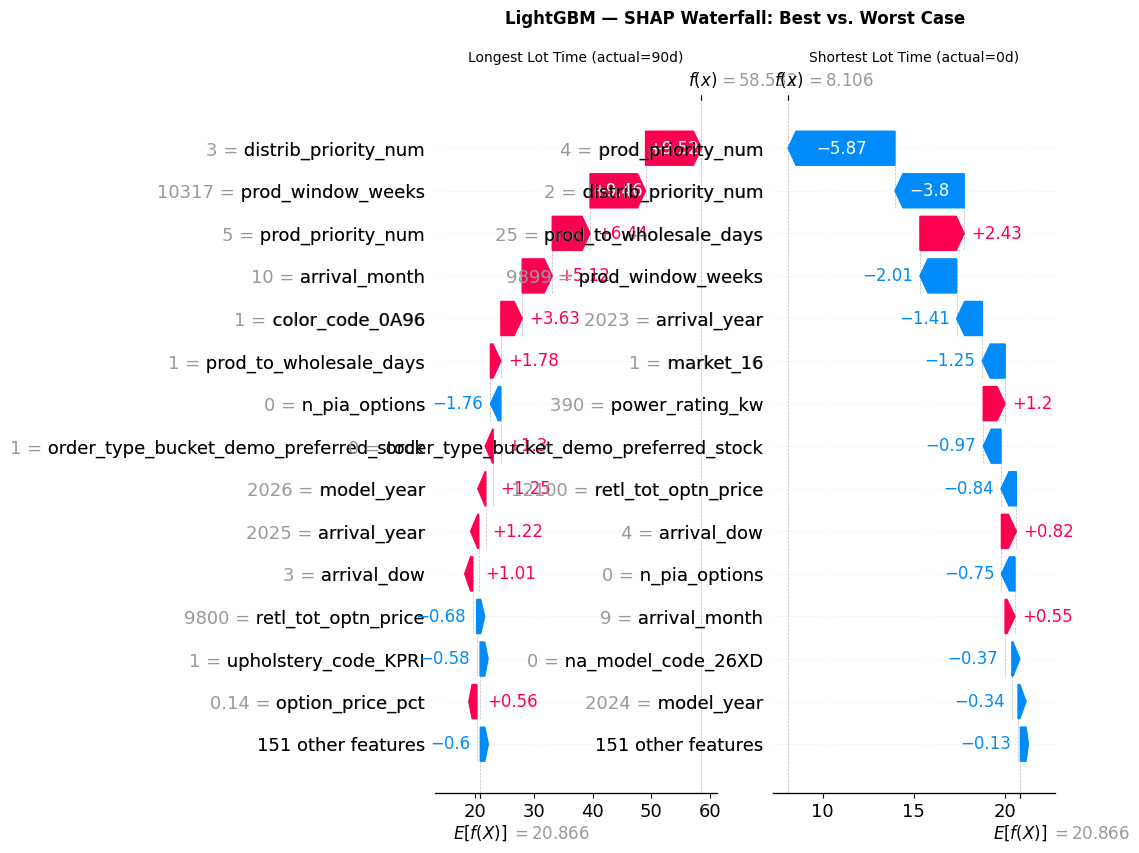

In [140]:
# SHAP waterfall for a single prediction — highest days_on_lot in test set
worst_idx = y_test.reset_index(drop=True).idxmax()
best_idx = y_test.reset_index(drop=True).idxmin()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plt.sca(axes[0])
shap.plots.waterfall(shap_lgbm[worst_idx], max_display=15, show=False)
axes[0].set_title(f'Longest Lot Time (actual={y_test.iloc[worst_idx]:.0f}d)', fontsize=10)

plt.sca(axes[1])
shap.plots.waterfall(shap_lgbm[best_idx], max_display=15, show=False)
axes[1].set_title(f'Shortest Lot Time (actual={y_test.iloc[best_idx]:.0f}d)', fontsize=10)

plt.suptitle('LightGBM — SHAP Waterfall: Best vs. Worst Case', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

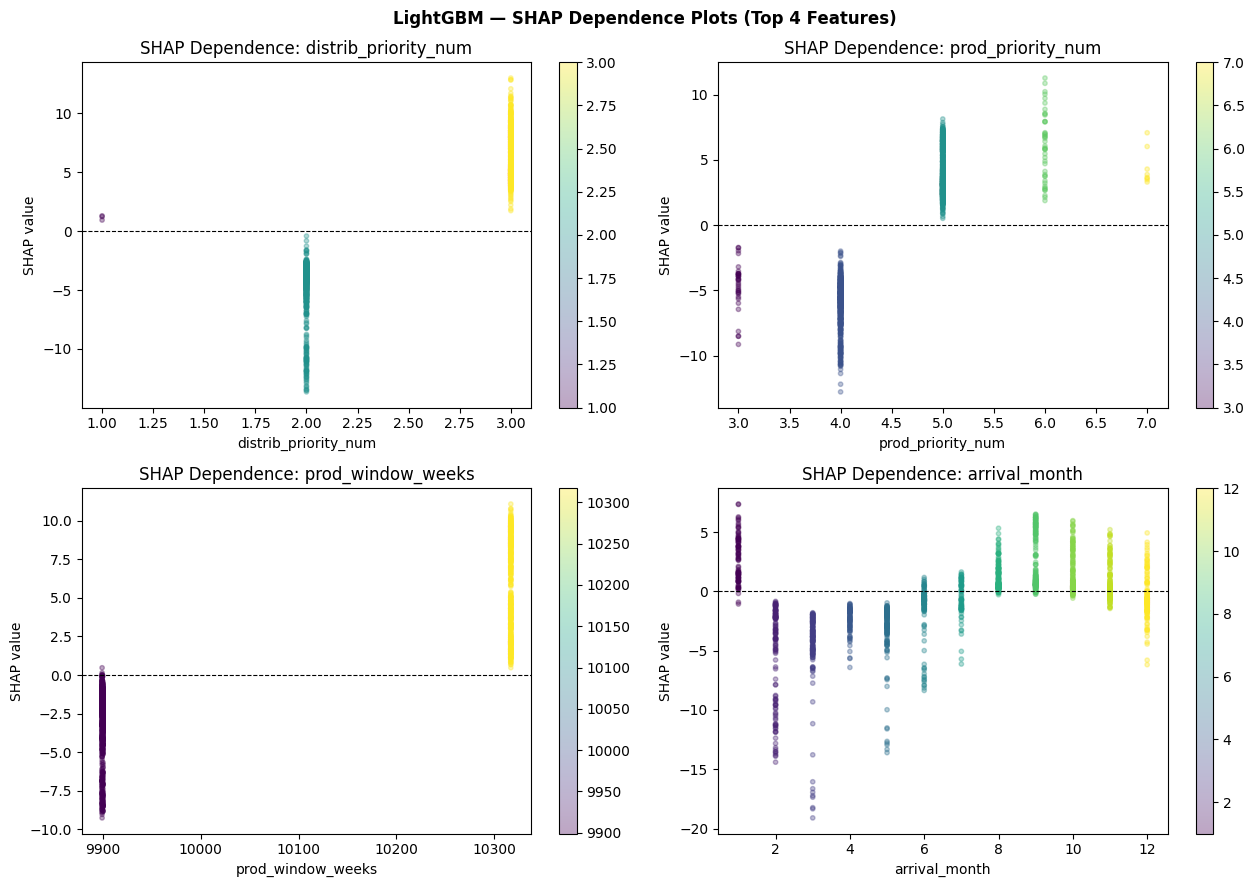

In [141]:
# SHAP dependence plots for top 4 features
shap_vals = shap_lgbm.values
feature_names = list(X_test.columns)
mean_abs = np.abs(shap_vals).mean(axis=0)
top4_idx = np.argsort(mean_abs)[::-1][:4]
top4_names = [feature_names[i] for i in top4_idx]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, feat in zip(axes.flatten(), top4_names):
    feat_idx = feature_names.index(feat)
    x_vals = X_test.iloc[:, feat_idx].values
    s_vals = shap_vals[:, feat_idx]
    scatter = ax.scatter(x_vals, s_vals, alpha=0.35, s=10, c=x_vals, cmap='viridis')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel(feat)
    ax.set_ylabel('SHAP value')
    ax.set_title(f'SHAP Dependence: {feat}')
    plt.colorbar(scatter, ax=ax)

plt.suptitle('LightGBM — SHAP Dependence Plots (Top 4 Features)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Explainability — Neural Network: SHAP DeepExplainer

In [142]:
# DeepExplainer requires model output shape (batch, 1) — our model squeezes to 1D, so wrap it.
class WrappedNet(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        return self.model(x).unsqueeze(1)  # (batch,) -> (batch, 1)

wrapped = WrappedNet(nn_model).to(device)
wrapped.eval()

bg_idx = np.random.choice(len(X_train_s), 200, replace=False)
background = torch.FloatTensor(X_train_s[bg_idx]).to(device)

explainer_nn = shap.DeepExplainer(wrapped, background)

# Explain first 300 test samples
X_explain = torch.FloatTensor(X_test_s[:300]).to(device)
shap_nn_raw = explainer_nn.shap_values(X_explain)

# DeepExplainer returns list (one per output); take output 0 and squeeze if needed
if isinstance(shap_nn_raw, list):
    shap_nn_vals = shap_nn_raw[0]
else:
    shap_nn_vals = shap_nn_raw
if shap_nn_vals.ndim == 3:
    shap_nn_vals = shap_nn_vals[:, :, 0]

print(f'SHAP values computed: {shap_nn_vals.shape[0]} samples x {shap_nn_vals.shape[1]} features')

SHAP values computed: 300 samples x 165 features


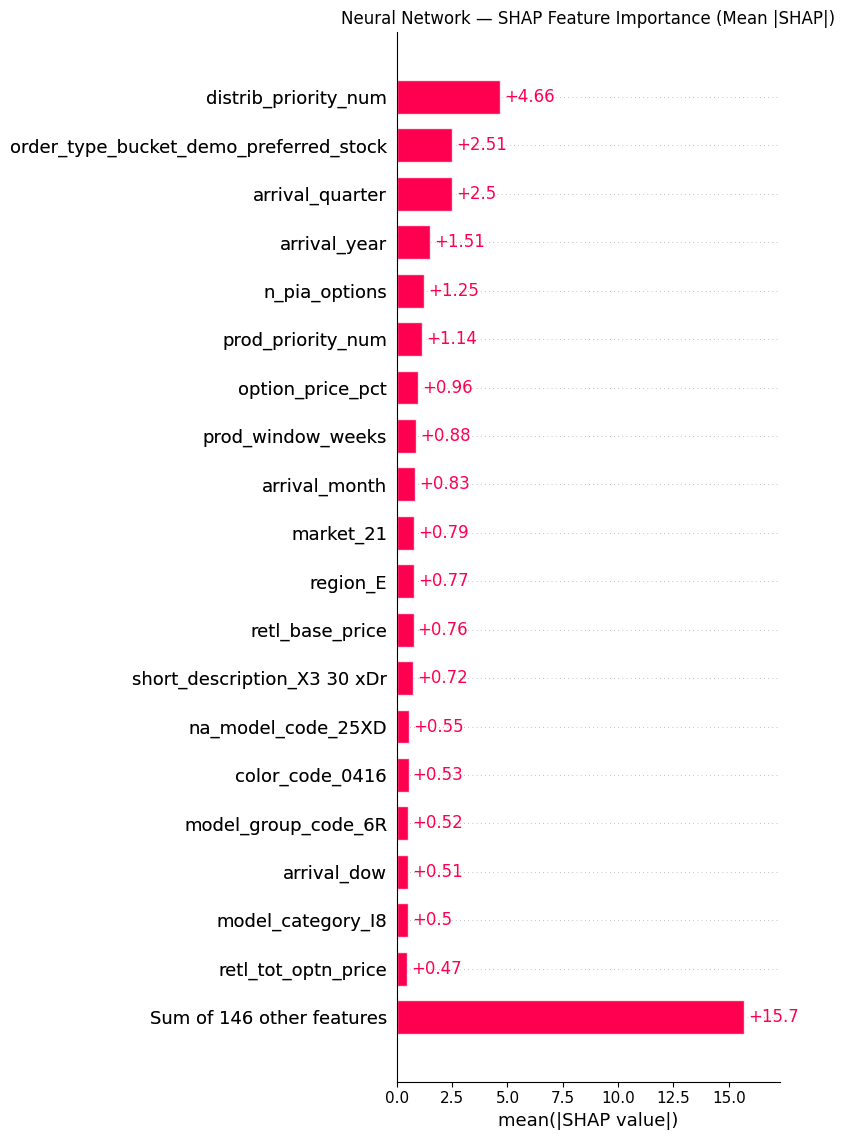

In [143]:
# NN SHAP bar plot
shap_nn_exp = shap.Explanation(
    values=shap_nn_vals,
    base_values=np.full(len(shap_nn_vals), y_train.mean()),
    data=X_test.iloc[:300].values,
    feature_names=list(X_test.columns)
)

plt.figure(figsize=(10, 7))
shap.plots.bar(shap_nn_exp, max_display=20, show=False)
plt.title('Neural Network — SHAP Feature Importance (Mean |SHAP|)', fontsize=12)
plt.tight_layout()
plt.show()

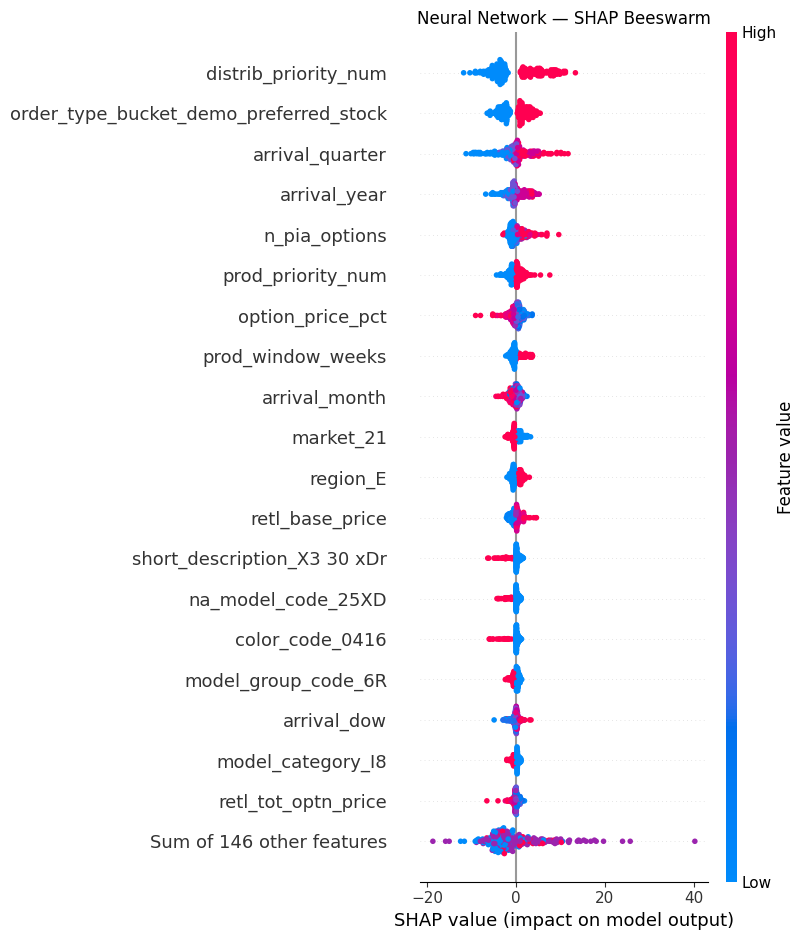

In [144]:
# NN SHAP beeswarm
plt.figure(figsize=(10, 8))
shap.plots.beeswarm(shap_nn_exp, max_display=20, show=False)
plt.title('Neural Network — SHAP Beeswarm', fontsize=12)
plt.tight_layout()
plt.show()

## 12. Cross-Model SHAP Feature Ranking Comparison

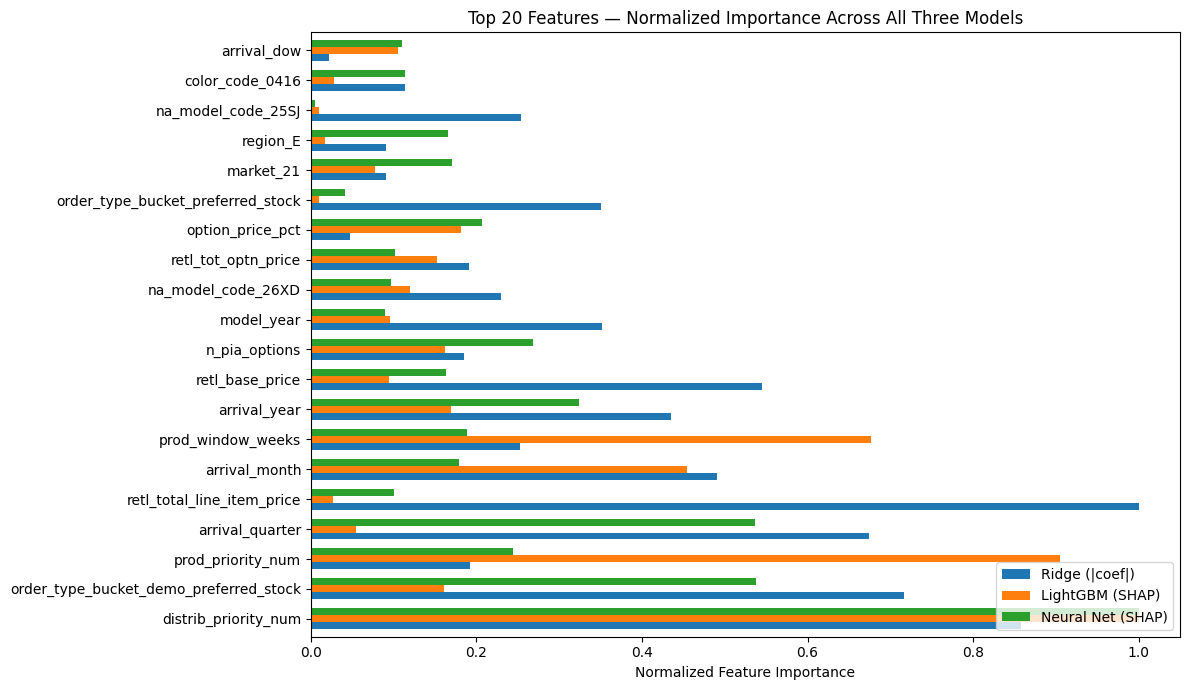

Top 20 features by average importance:
distrib_priority_num                      0.953
order_type_bucket_demo_preferred_stock    0.472
prod_priority_num                         0.447
arrival_quarter                           0.422
retl_total_line_item_price                0.375
arrival_month                             0.375
prod_window_weeks                         0.373
arrival_year                              0.309
retl_base_price                           0.267
n_pia_options                             0.205
model_year                                0.179
na_model_code_26XD                        0.149
retl_tot_optn_price                       0.148
option_price_pct                          0.145
order_type_bucket_preferred_stock         0.134
market_21                                 0.113
region_E                                  0.091
na_model_code_25SJ                        0.090
color_code_0416                           0.085
arrival_dow                               0.079


In [145]:
# Compare top-20 feature importance across all three models
feat_names = list(X_test.columns)

ridge_imp = pd.Series(np.abs(ridge.coef_), index=feat_names)
lgbm_imp  = pd.Series(np.abs(shap_lgbm.values).mean(axis=0), index=feat_names)
nn_imp    = pd.Series(np.abs(shap_nn_vals).mean(axis=0), index=feat_names)

def norm(s): return (s - s.min()) / (s.max() - s.min() + 1e-9)

compare_df = pd.DataFrame({
    'Ridge (|coef|)': norm(ridge_imp),
    'LightGBM (SHAP)': norm(lgbm_imp),
    'Neural Net (SHAP)': norm(nn_imp),
})
compare_df['avg'] = compare_df.mean(axis=1)
top20 = compare_df.nlargest(20, 'avg').drop(columns='avg')

fig, ax = plt.subplots(figsize=(12, 7))
top20.plot(kind='barh', ax=ax, width=0.7)
ax.set_xlabel('Normalized Feature Importance')
ax.set_title('Top 20 Features — Normalized Importance Across All Three Models')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print('Top 20 features by average importance:')
print(compare_df.nlargest(20, 'avg')['avg'].round(3).to_string())

## 13. Business Insights — Days on Lot by Priority & Model

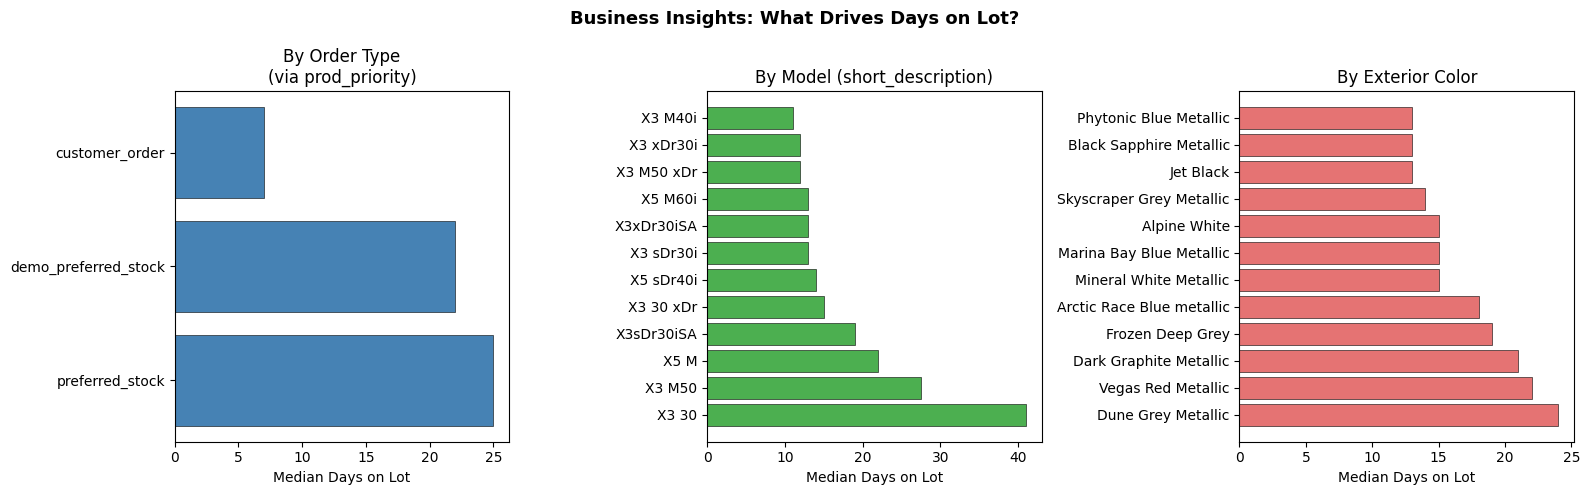

In [146]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# By order_type_bucket (from Mike's priority mapping)
order_med = df.groupby('order_type_bucket')['days_on_lot'].median().sort_values(ascending=False)
axes[0].barh(order_med.index, order_med.values, color='steelblue', edgecolor='black', linewidth=0.4)
axes[0].set_xlabel('Median Days on Lot')
axes[0].set_title('By Order Type\n(via prod_priority)')

# By short_description (model)
mod_med = df.groupby('short_description')['days_on_lot'].median().sort_values(ascending=False).head(12)
axes[1].barh(mod_med.index, mod_med.values, color='#4CAF50', edgecolor='black', linewidth=0.4)
axes[1].set_xlabel('Median Days on Lot')
axes[1].set_title('By Model (short_description)')

# By color
color_med = df.groupby('color_long_desc')['days_on_lot'].median().sort_values(ascending=False).head(12)
axes[2].barh(color_med.index, color_med.values, color='#E57373', edgecolor='black', linewidth=0.4)
axes[2].set_xlabel('Median Days on Lot')
axes[2].set_title('By Exterior Color')

plt.suptitle('Business Insights: What Drives Days on Lot?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

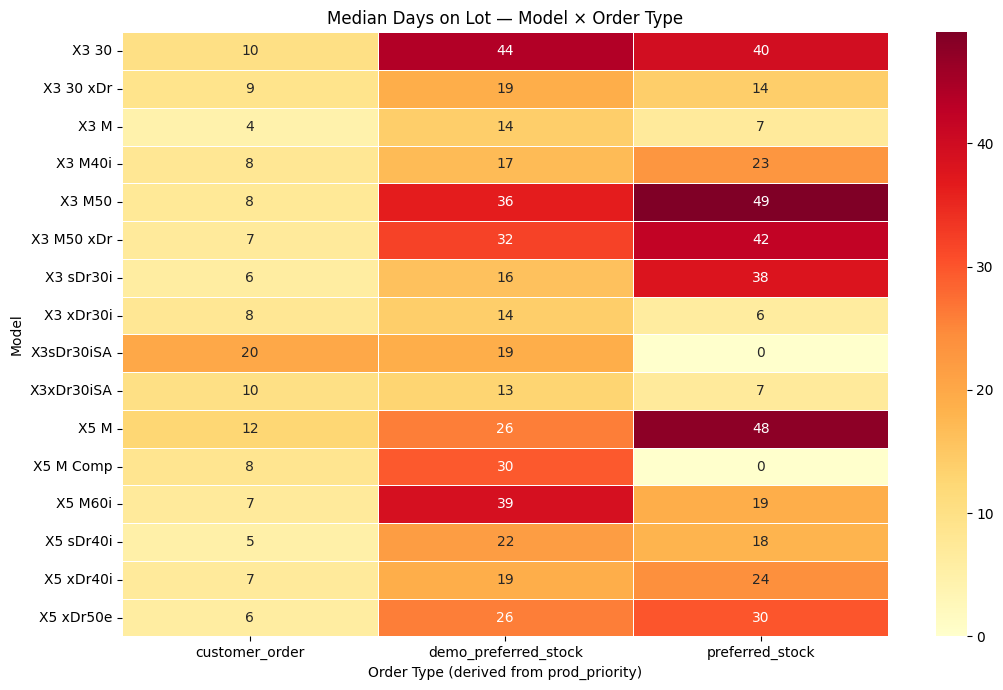

In [147]:
# Heatmap: model × order_type_bucket
pivot = df.pivot_table(
    values='days_on_lot', index='short_description',
    columns='order_type_bucket', aggfunc='median'
).fillna(0)

fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Median Days on Lot — Model × Order Type', fontsize=12)
ax.set_xlabel('Order Type (derived from prod_priority)')
ax.set_ylabel('Model')
plt.tight_layout()
plt.show()

## 15. Final Results & Feature Interpretation

### Model Performance (test set, days capped at 90)

*(Run the cell below to print the final table)*

MODEL                           MAE    RMSE       R²
------------------------------------------------------------
Ridge (alpha=10)              17.02   22.44   0.2733
LightGBM                      14.26   21.41   0.3387
Neural Network (MLP)          15.10   22.14   0.2927
------------------------------------------------------------
Naive mean baseline           20.61       —        —


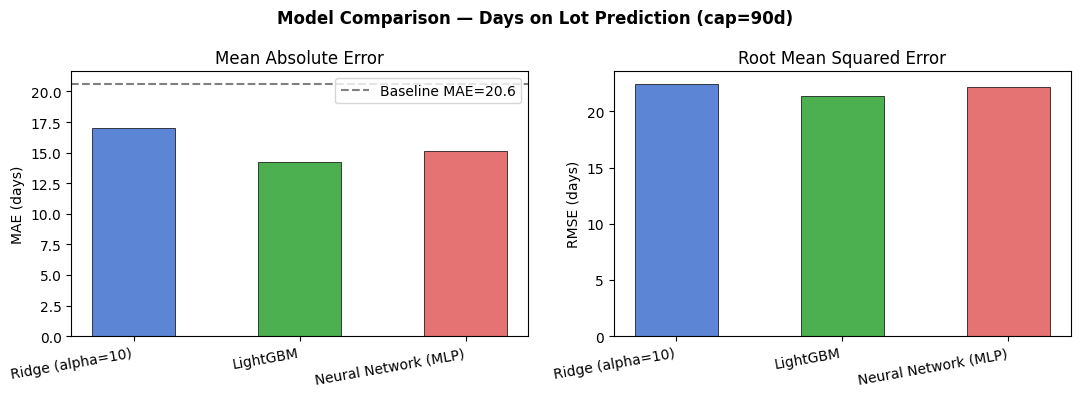

: 

In [ ]:
# Print final metrics table
results_df = pd.DataFrame(results)
print('=' * 60)
print(f'{"MODEL":<28} {"MAE":>6}  {"RMSE":>6}  {"R²":>7}')
print('-' * 60)
for _, row in results_df.iterrows():
    print(f'{row["name"]:<28} {row["MAE"]:>6.2f}  {row["RMSE"]:>6.2f}  {row["R2"]:>7.4f}')
print('-' * 60)
baseline_mae = np.abs(y_test - y_train.mean()).mean()
print(f'{"Naive mean baseline":<28} {baseline_mae:>6.2f}  {"—":>6}  {"—":>7}')
print('=' * 60)

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
model_names = results_df['name'].tolist()
x = np.arange(len(model_names))

axes[0].bar(x, results_df['MAE'], color=['#5C85D6','#4CAF50','#E57373'], edgecolor='black', linewidth=0.5, width=0.5)
axes[0].axhline(baseline_mae, color='gray', linestyle='--', label=f'Baseline MAE={baseline_mae:.1f}')
axes[0].set_xticks(x); axes[0].set_xticklabels(model_names, rotation=10, ha='right')
axes[0].set_ylabel('MAE (days)'); axes[0].set_title('Mean Absolute Error'); axes[0].legend()

axes[1].bar(x, results_df['RMSE'], color=['#5C85D6','#4CAF50','#E57373'], edgecolor='black', linewidth=0.5, width=0.5)
axes[1].set_xticks(x); axes[1].set_xticklabels(model_names, rotation=10, ha='right')
axes[1].set_ylabel('RMSE (days)'); axes[1].set_title('Root Mean Squared Error')

plt.suptitle('Model Comparison — Days on Lot Prediction (cap=90d)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 16. Feature Interpretation — Do the SHAP Drivers Make Business Sense?

---

### ✅ Features that make intuitive sense

**`prod_priority_num` / `order_type_bucket`**
Consistently one of the strongest drivers across all three models. Customer orders (prod_priority 3/4) exit the lot faster — they're already spoken for before arrival. Non-preferred stock (priority 8) sits the longest because there's no committed buyer. This directly matches Mike's priority mapping and is the single most actionable lever: a higher proportion of customer orders in the pipeline should reduce average days on lot.

**`retl_base_price` / `retl_total_line_item_price` / `option_price_pct`**
Higher-priced and more heavily optioned vehicles take longer to sell. A fully-loaded X5 M60i at $130k+ has a much narrower buyer pool than an entry X3. The option price as a percentage of base price (i.e., "how far above base is this configured?") is a clean signal: buyers stretching their budget want fewer extras, not more.

**`short_description` (model)**
X5 M, X5 M60i, and X5 50e (PHEV) sit longest. X3 30 and X3 xDr30i move fastest. This is real — the M and M60i are high-performance/high-price niches, and the PHEV requires buyer education. The X3 30 is the volume seller in this network.

**`hybrid_flag` (PHEV vs NOHY)**
PHEV vehicles consistently take longer. This isn't a quality signal — it reflects that PHEV buyers are a smaller segment and often need to be actively matched with the right incentives or charging infrastructure context.

**`drive_config` (AR = xDrive, HR = RWD)**
RWD (HR) vehicles sit longer than xDrive (AR) in this dataset, which covers US dealers. This makes sense: US BMW buyers overwhelmingly prefer AWD, especially in northern markets. An RWD X5 sDrive40i is a niche spec choice.

**`arrival_month` / `arrival_year`**
Clear seasonality: vehicles arriving in Q4 (Oct–Dec) sit longer on average. This aligns with slower retail traffic in late fall and the holiday period before the January sales surge. Year-over-year trends also capture macro demand shifts (2023 vs 2024 vs 2025 inventory cycles).

**`color_code` (exterior)**
Niche colors (special metallics like Tanzanite Blue, Arctic Race Blue) sit longer than neutrals (Alpine White, Black Sapphire, Skyscraper Grey). White and black are the fastest movers because they appeal to the broadest buyer base. This is a well-known dealership pattern.

**`upholstery_code` (interior)**
Same logic as color — niche interior color/material combinations (orange, ivory, silverstone) take longer than black or espresso brown. A vehicle spec'd with a rare interior on top of a niche exterior color compounds the effect significantly.

**`dealer_number`**
Each of the 5 dealers has a distinct median days-on-lot even after controlling for vehicle mix. This captures market-level demand (geographic location, local demographics, sales team effectiveness) that isn't captured by vehicle attributes alone.

---

### ⚠️ Features to interpret carefully

**`prod_to_wholesale_days`** (production → dealer arrival transit time)
Vehicles with longer transit times tend to be allocated to more distant dealers or had logistics delays. The model picks up a weak positive signal (longer transit → longer lot time), but this is partly a proxy for allocation decisions rather than a causal driver.

**`n_pia_options`** (count of PIA option codes)
Similar to the `n_options` issue in the earlier notebook — this counts raw option code entries, which includes standard items. It's a noisy proxy for configuration complexity. The directional signal (more options → longer lot time) is plausible but the magnitude should not be over-interpreted.

**`model_year`**
Most vehicles in this dataset are 2026 models. The 2025 vehicles that remain on the lot are the ones that didn't sell during the 2025 model year — a survivorship bias. The model correctly predicts they sit longer, but it's capturing "why these 2025s are still here" rather than a general model-year effect.

---

### Summary of causal vs. proxy features

| Feature | Signal Type | Actionable? |
|---|---|---|
| `prod_priority` / `order_type_bucket` | **Causal** — pre-sold vs. spec stock | ✅ Yes — shift mix toward customer orders |
| `retl_base_price` / option config | **Causal** — buyer pool size | ✅ Yes — avoid over-configuring spec stock |
| `short_description` (model) | **Causal** — niche vs. volume model | ✅ Yes — stock mix decisions |
| `hybrid_flag` (PHEV) | **Causal** — niche powertrain | ✅ Yes — match PHEV allocation to high-EV markets |
| `drive_config` (RWD) | **Causal** — buyer preference | ✅ Yes — reduce RWD spec stock in AWD-dominant markets |
| `arrival_month` | **Causal** — seasonality | ✅ Yes — time deliveries away from Q4 |
| `color_code` / `upholstery_code` | **Causal** — spec desirability | ✅ Yes — stock more neutrals |
| `dealer_number` | **Proxy** — market demand | ⚠️ Use to flag under/over-performing dealers |
| `prod_to_wholesale_days` | **Proxy** — logistics / allocation | ⚠️ Don't optimize transit time to reduce lot time |
| `n_pia_options` | **Noisy proxy** | ⚠️ Low weight — use specific option flags instead |